# ETFs: Label Engineering

Every model in this case study is trained to predict the label. An error in it produces no
warning here and changes every result that follows, so this notebook defines the labels,
checks the definition, sets the floor a feature must clear, and writes the files stage 03
reads.

## Learning objectives

- Write a forward-return label as a formula: from which price at which time, to which
  price at which time
- Check that every labelled row has a complete forward window inside one symbol
- Measure how much independent information an overlapping label carries, and seal a
  diagnostic on the date a label resolves rather than the date it is observed
- Measure the baseline a feature has to beat, on the panel features are scored on

## Book reference, prerequisites and artifacts

Chapter 7, Section 7.2. Reads split- and dividend-adjusted daily bars via `load_etfs()`
(verified in [`01_feasibility_analysis`](01_feasibility_analysis.ipynb)) and
`config/setup.yaml`, which declares the label set, horizons and holdout boundary. Writes
`labels/fwd_ret_21d.parquet` and `labels/fwd_ret_5d.parquet`; `03_financial_features.py`
reads whichever of the two `setup.yaml` names as primary.

In [1]:
"""ETFs: Label Engineering."""

import math
import warnings
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from ml4t.diagnostic.metrics import compute_ic_hac_stats, cross_sectional_ic_series

from case_studies.utils.artifact_digest import value_digest, write_artifact
from case_studies.utils.label_diagnostics import effective_sample_size, panel_autocorrelation
from data import load_etfs
from utils.artifact_specs import resolve_label_horizon
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title

warnings.filterwarnings("ignore")

CASE_DIR = get_case_study_dir("etfs")
LABELS_DIR = CASE_DIR / "labels"

`MAX_SYMBOLS` and `START_DATE` cut the universe and the history for a shorter run; both are
unset here. `MIN_SYMBOLS_FOR_DISPERSION` sets the smallest cross-section Section E will take
a standard deviation over.

In [2]:
MAX_SYMBOLS = None
START_DATE = None
MIN_SYMBOLS_FOR_DISPERSION = 10

## Configuration

Every value that defines a label comes from `config/setup.yaml`: the label set, the
horizons and the holdout boundary. `resolve_label_horizon` reads `labels.horizons` where a
case study declares it and falls back to the cross-validation buffer, which here is the
same number.

In [3]:
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

PRIMARY_LABEL = setup["labels"]["primary"]
LABEL_NAMES = [PRIMARY_LABEL, *setup["labels"].get("variants", [])]
HORIZONS = {n: int(resolve_label_horizon("etfs", n, setup).rstrip("Dd")) for n in LABEL_NAMES}
HOLDOUT_START = date.fromisoformat(setup["evaluation"]["holdout_start"])
PRIMARY_HORIZON = HORIZONS[PRIMARY_LABEL]
VARIANT_LABEL = LABEL_NAMES[1]

print(f"Labels: {LABEL_NAMES} (primary: {PRIMARY_LABEL})")
print(f"Horizons, trading sessions: {HORIZONS}")
print(f"Holdout starts {HOLDOUT_START}; diagnostics below are sealed on the label endpoint")

Labels: ['fwd_ret_21d', 'fwd_ret_5d'] (primary: fwd_ret_21d)
Horizons, trading sessions: {'fwd_ret_21d': 21, 'fwd_ret_5d': 5}
Holdout starts 2024-01-01; diagnostics below are sealed on the label endpoint


## A. The learning task

The hypothesis is cross-sectional: among a fixed universe of liquid ETFs, those that rose
over the past two quarters continue to outrank those that did not over the following month.
The label is therefore a *relative* forward return over a window a monthly hold spans.
`setup.yaml` sets the decision cadence to a month-end close with execution at the next open,
which fixes the primary horizon at one trading month. The weekly variant asks whether the
same hypothesis pays over a shorter hold, which is a question about turnover and cost.

Labels are sampled every session rather than only at month ends. That gives an order of
magnitude more rows, and consecutive rows then overlap; Section F measures how much
independent information they carry.

## B. Preparation before the label

A forward window is meaningful only on a price series that is adjusted, ordered and
complete; sorting by `symbol` then `timestamp` is what makes a shift mean "the next session
for this ETF".

The labels are built on the full price history, and the eligibility rules in
`eligibility.csv` are applied afterwards - to the Section G baseline, and to the trainable
panel in `03_financial_features`. The order is what keeps the horizon in trading sessions:
a shift of $h$ counts $h$ rows of whatever frame it runs on, so it has to run on the frame
that still has every session in it.

The hash printed below covers exactly the columns the labels are built from. Section H
writes it beside each label file.

In [4]:
prices = load_etfs().select(["symbol", "timestamp", "close"]).sort(["symbol", "timestamp"])

if START_DATE is not None:
    prices = prices.filter(pl.col("timestamp") >= date.fromisoformat(START_DATE))
if MAX_SYMBOLS is not None:
    prices = prices.filter(
        pl.col("symbol").is_in(sorted(prices["symbol"].unique().to_list())[:MAX_SYMBOLS])
    )

MARKET_DATA_DIGEST = value_digest(prices, ["symbol", "timestamp", "close"])

print(f"{prices['symbol'].n_unique()} ETFs, {len(prices):,} rows")
print(f"Sessions {prices['timestamp'].min()} to {prices['timestamp'].max()}")
print(f"market_data digest: {MARKET_DATA_DIGEST}")

100 ETFs, 470,662 rows
Sessions 2006-01-03 to 2025-12-31
market_data digest: eef04b58a9ea0b97


## C. Label construction

One execution convention, written once, applied to both horizons:

$$r^{(h)}_{i,t} = \frac{P_{i,t+h}}{P_{i,t}} - 1$$

where $P$ is the adjusted close and $t+h$ counts $h$ **trading sessions** for symbol $i$.
This is Chapter 7.2's close-to-close convention. The two labels, written to columns
`fwd_ret_21d` and `fwd_ret_5d`, share the anchor and differ only in $h$.

In [5]:
def forward_return(df: pl.DataFrame, horizon: int, name: str) -> pl.DataFrame:
    """Close-to-close forward return over `horizon` trading sessions, per symbol."""
    return df.with_columns(
        (pl.col("close").shift(-horizon).over("symbol") / pl.col("close") - 1).alias(name)
    )


labels_df = prices.with_columns(
    (pl.len().over("symbol") - 1 - pl.int_range(pl.len()).over("symbol")).alias("from_end")
)
for label_name, horizon in HORIZONS.items():
    labels_df = forward_return(labels_df, horizon, label_name)

print(f"Constructed {', '.join(LABEL_NAMES)}")

Constructed fwd_ret_21d, fwd_ret_5d


## D. Window validity

A shift always returns something; the question is whether it is the quantity the label
claims. Four properties have to hold, and each fails without raising an error, so the cell
below checks them with `assert`:

1. A row whose forward window is incomplete carries a null, never a value.
2. No labelled window spans a gap in the data. The tolerance is derived rather than tuned:
   $h$ trading sessions cover about $7h/5$ calendar days on a five-session week, plus a
   week for exchange holidays.
3. No label crosses from one symbol into the next. The labelled row count equals the bar
   count less $h$ rows per symbol, which holds only if every window closed inside the
   symbol it opened in.
4. No discrete label is derived from a null return. Both labels here are continuous, so
   this is a check on their dtype.

Property 2 measures the window in calendar days, so it catches a hole of a week or more and
not a single missing session. An exact session count needs an exchange calendar.

In [6]:
for label_name, horizon in HORIZONS.items():
    tol = math.ceil(horizon * 7 / 5) + 7
    # How many calendar days the forward window actually spans, for property 2.
    spanned = labels_df.with_columns(
        (pl.col("timestamp").shift(-horizon).over("symbol") - pl.col("timestamp"))
        .dt.total_days()
        .alias("_span")
    )
    tail = spanned.filter(pl.col("from_end") < horizon)
    labelled = spanned.drop_nulls(label_name)

    # 1.
    assert tail[label_name].null_count() == tail.height, f"{label_name}: valued incomplete window"
    # 2.
    assert labelled.filter(pl.col("_span") > tol).height == 0, f"{label_name}: window gap"
    # 3.
    assert labelled.height == len(prices) - horizon * prices["symbol"].n_unique(), (
        f"{label_name}: label crosses a symbol boundary"
    )
    # 4.
    assert labels_df.schema[label_name] == pl.Float64, f"{label_name}: unexpected dtype"

    spans = labelled["_span"]
    print(
        f"{label_name}: {labelled.height:,} labelled rows, spans {spans.min()}-{spans.max()}d "
        f"against a {tol}d tolerance, {tail.height:,} tail rows null"
    )

fwd_ret_21d: 468,562 labelled rows, spans 29-35d against a 37d tolerance, 2,100 tail rows null
fwd_ret_5d: 470,162 labelled rows, spans 7-12d against a 14d tolerance, 500 tail rows null


The assertions stop the run, but they do not show *where* each label ends. The figure below
does. Position zero is each symbol's last session, and the share of symbols carrying a label
falls to zero over exactly the last `horizon` positions and sits flat at one before them.

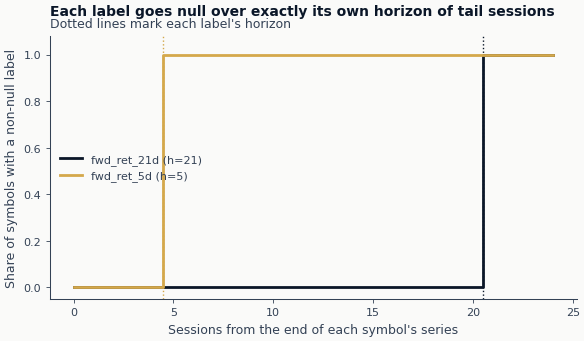

In [7]:
profile = (
    labels_df.filter(pl.col("from_end") <= max(HORIZONS.values()) + 3)
    .group_by("from_end")
    .agg([pl.col(n).is_not_null().mean().alias(n) for n in LABEL_NAMES])
    .sort("from_end")
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for label_name, color in zip(LABEL_NAMES, (COLORS["blue"], COLORS["amber"]), strict=True):
    ax.step(
        profile["from_end"],
        profile[label_name],
        where="mid",
        color=color,
        linewidth=2,
        label=f"{label_name} (h={HORIZONS[label_name]})",
    )
    ax.axvline(HORIZONS[label_name] - 0.5, color=color, linestyle=":", linewidth=1)
ax.set_xlabel("Sessions from the end of each symbol's series")
ax.set_ylabel("Share of symbols with a non-null label")
ax.set_ylim(-0.05, 1.08)
add_message_title(
    ax,
    "Each label goes null over exactly its own horizon of tail sessions",
    subtitle="Dotted lines mark each label's horizon",
)
ax.legend(loc="center left", frameon=False)
plt.show()

## E. Distribution and base rate

What scale is the label, and is it stable enough through time that a model fitted on one
regime measures the same quantity in another? Everything from here through Section G is
computed on the **development window only**, sealed on the date each label resolves rather
than the date it is observed: a row observed just before the holdout still resolves inside
it. The label files themselves keep every row.

In [8]:
dev = {
    name: labels_df.with_columns(
        pl.col("timestamp").shift(-horizon).over("symbol").alias("_label_end")
    )
    .filter(pl.col("_label_end") < HOLDOUT_START)
    .drop_nulls(name)
    for name, horizon in HORIZONS.items()
}
for label_name, frame in dev.items():
    print(f"{label_name}: {frame.height:,} development rows through {frame['timestamp'].max()}")

fwd_ret_21d: 418,362 development rows through 2023-11-29
fwd_ret_5d: 419,962 development rows through 2023-12-21


Both labels are drawn on one axis with identical bins, so their shapes can be compared
directly. What to look for: a label over $h$ sessions should be about $\sqrt{h}$ times as
wide as a one-session label, and the legend carries each one's standard deviation.

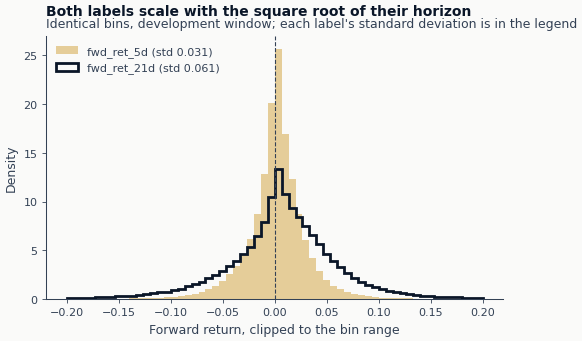

In [9]:
bins = np.linspace(-0.20, 0.20, 61)
std = {n: dev[n][n].std() for n in LABEL_NAMES}
ratio = std[PRIMARY_LABEL] / std[VARIANT_LABEL]
theory = math.sqrt(PRIMARY_HORIZON / HORIZONS[VARIANT_LABEL])

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
fills = {VARIANT_LABEL: dict(color=COLORS["amber"], alpha=0.55)}
fills[PRIMARY_LABEL] = dict(color=COLORS["blue"], histtype="step", linewidth=2)
for label_name in (VARIANT_LABEL, PRIMARY_LABEL):
    ax.hist(
        dev[label_name][label_name].to_numpy(),
        bins=bins,
        density=True,
        label=f"{label_name} (std {std[label_name]:.3f})",
        **fills[label_name],
    )
ax.axvline(0, color=COLORS["neutral"], linestyle="--", linewidth=0.8)
ax.set_xlabel("Forward return, clipped to the bin range")
ax.set_ylabel("Density")
add_message_title(
    ax,
    "Both labels scale with the square root of their horizon",
    subtitle="Identical bins, development window; each label's standard deviation is in the legend",
)
ax.legend(loc="upper left", frameon=False)
plt.show()

The second stability question is about the spread the model ranks within. A cross-sectional
model is scored on how well it orders symbols on a date, so the return that ordering earns
depends on how far apart the symbols are that day: at twice the spread, the same
information coefficient returns twice as much.

The spread is measured across symbols within each date, and those daily values are then
averaged over the year.

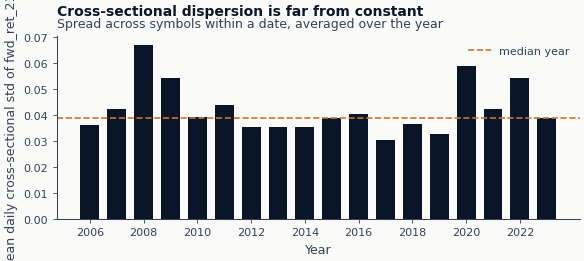

scale: std ratio 1.97 against 2.05 under root-horizon scaling; dispersion peaks at 6.7% in 2008 against a 3.9% median year


In [10]:
daily_dispersion = (
    dev[PRIMARY_LABEL]
    .group_by("timestamp")
    .agg(pl.col(PRIMARY_LABEL).std().alias("dispersion"), pl.len().alias("n_symbols"))
    .filter(pl.col("n_symbols") >= MIN_SYMBOLS_FOR_DISPERSION)
)
annual = (
    daily_dispersion.with_columns(pl.col("timestamp").dt.year().alias("year"))
    .group_by("year")
    .agg(pl.col("dispersion").mean().alias("dispersion"))
    .sort("year")
)
peak = annual.sort("dispersion", descending=True).row(0, named=True)
median_disp = annual["dispersion"].median()

fig, ax = plt.subplots(figsize=FIGSIZE["single_wide"])
ax.bar(annual["year"], annual["dispersion"], color=COLORS["blue"], width=0.7)
ax.axhline(median_disp, color=COLORS["copper"], linestyle="--", linewidth=1.2, label="median year")
ax.set_xticks(annual["year"].to_list()[::2])  # integer years, not a float axis
ax.set_xlabel("Year")
ax.set_ylabel(f"Mean daily cross-sectional std of {PRIMARY_LABEL}")
add_message_title(
    ax,
    "Cross-sectional dispersion is far from constant",
    subtitle="Spread across symbols within a date, averaged over the year",
)
ax.legend(loc="upper right", frameon=False)
plt.show()

print(
    f"scale: std ratio {ratio:.2f} against {theory:.2f} under root-horizon scaling; "
    f"dispersion peaks at {peak['dispersion']:.1%} in {peak['year']:.0f} "
    f"against a {median_disp:.1%} median year"
)

On the development window the monthly label has a standard deviation of 0.0612 against
0.0311 for the weekly label - a ratio of 1.97, close to the 2.05 that
square-root-of-horizon scaling would give. Cross-sectional dispersion is far from
constant: it peaks at 6.7% in 2008, against a median year of 3.9%.

## F. Overlap and effective sample size

Daily sampling of a multi-session label makes consecutive rows share most of their forward
window, so the row count overstates how much the sample actually tells us. Two measurements
follow: how fast the overlap decays, and what the row count is worth once the overlap is
accounted for. `effective_sample_size` applies Chapter 7.2's average-uniqueness weighting
one symbol at a time, since it is only one symbol's own windows that overlap each other.

A label over $h$ sessions is built from the $h$ returns realised inside its window, and the
label one session later shares $h-1$ of them. Average uniqueness therefore approaches $1/h$
and the effective count approaches $N/h$.

The figure below shows how fast the overlap decays, pooled across the whole panel so that
the answer is a property of the label rather than of any one ETF.

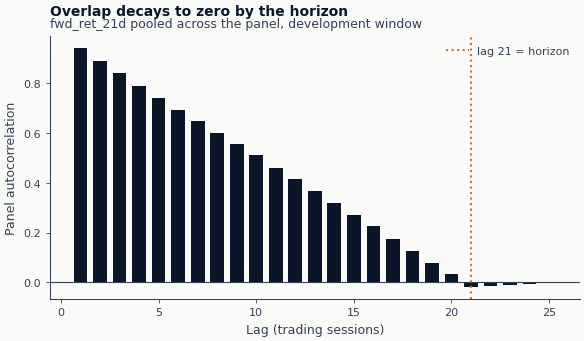

fwd_ret_21d: N=418,362 N_eff=20,017 (4.78% of N, against 4.76% for windows that overlap as fully as this one)
  autocorrelation at lag one 0.942, at the horizon -0.019


In [11]:
max_lag = PRIMARY_HORIZON + 4
acf = panel_autocorrelation(dev[PRIMARY_LABEL], PRIMARY_LABEL, max_lag=max_lag)
n_rows, n_eff = effective_sample_size(dev[PRIMARY_LABEL], horizon=PRIMARY_HORIZON)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.bar(np.arange(1, max_lag + 1), acf, color=COLORS["blue"], width=0.7)
ax.axhline(0, color=COLORS["neutral"], linewidth=0.8)
ax.axvline(
    PRIMARY_HORIZON,
    color=COLORS["copper"],
    linestyle=":",
    linewidth=1.5,
    label=f"lag {PRIMARY_HORIZON} = horizon",
)
ax.set_xlabel("Lag (trading sessions)")
ax.set_ylabel("Panel autocorrelation")
add_message_title(
    ax,
    "Overlap decays to zero by the horizon",
    subtitle=f"{PRIMARY_LABEL} pooled across the panel, development window",
)
ax.legend(loc="upper right", frameon=False)
plt.show()

print(
    f"{PRIMARY_LABEL}: N={n_rows:,} N_eff={n_eff:,.0f} ({n_eff / n_rows:.2%} of N, against "
    f"{1 / PRIMARY_HORIZON:.2%} for windows that overlap as fully as this one)"
)
print(f"  autocorrelation at lag one {acf[0]:.3f}, at the horizon {acf[PRIMARY_HORIZON - 1]:.3f}")

The monthly label's 418,362 development rows carry 20,017 effective observations, 4.78% of
the row count against the 4.76% implied by a window this fully overlapped. Panel
autocorrelation runs from 0.942 at lag one to -0.019 at the horizon.

## G. Baseline floor

One signal, against the primary label, on the sealed development window: the raw momentum
the hypothesis names, with no feature engineering. Measuring it first is what keeps a later
improvement honest, because every engineered feature is then compared against a number that
was fixed before the feature existed.

The signal is scored the same way every feature will be. The IC is the cross-sectional rank
correlation, computed within each date and then averaged over dates. The minimum
cross-section is set at half the median, so it means the same thing on a universe of a
different size. The standard error is HAC-adjusted, because the IC series inherits the
label's overlap and correlated dates are not independent evidence.

The baseline is measured on the same rows the features will be measured on:
`03_financial_features` keeps a feature row only where the `(symbol, year)` pair appears in
`eligibility.csv`, so the same semi-join runs here.

In [12]:
LOOKBACK = 126  # two quarters, the momentum window the hypothesis names

eligibility = pl.read_csv(CASE_DIR / "eligibility.csv").select(
    "symbol", pl.col("eligible_year").alias("_year")
)
baseline = (
    dev[PRIMARY_LABEL]
    .with_columns(
        (pl.col("close") / pl.col("close").shift(LOOKBACK).over("symbol") - 1).alias("momentum")
    )
    .drop_nulls("momentum")
    .with_columns(pl.col("timestamp").dt.year().alias("_year"))
    .join(eligibility, on=["symbol", "_year"], how="semi")
    .drop("_year")
)
min_obs = int(baseline.group_by("timestamp").len()["len"].median() // 2)

In [13]:
ic = cross_sectional_ic_series(
    baseline,
    baseline,
    pred_col="momentum",
    ret_col=PRIMARY_LABEL,
    date_col="timestamp",
    entity_col="symbol",
    min_obs=min_obs,
).sort("timestamp")  # HAC autocovariances are meaningless over a permutation of time
stats = compute_ic_hac_stats(ic, ic_col="ic", label_horizon=PRIMARY_HORIZON)

print(
    f"Baseline: {LOOKBACK}-session momentum vs {PRIMARY_LABEL}, min cross-section {min_obs}, "
    f"eligible panel {baseline.height:,} rows"
)
print(f"  dates {ic.height:,}, mean IC {stats['mean_ic']:.4f}")
print(
    f"  HAC t {stats['t_stat']:.2f} (Bartlett, {stats['effective_lags']} lags), "
    f"naive t {stats['naive_t_stat']:.2f}, p {stats['p_value']:.3f}"
)

Baseline: 126-session momentum vs fwd_ret_21d, min cross-section 44, eligible panel 347,484 rows
  dates 4,257, mean IC 0.0203
  HAC t 1.08 (Bartlett, 20 lags), naive t 3.77, p 0.282


On the point-in-time eligible panel - the one `03_financial_features` scores features on -
raw momentum earns a mean IC of 0.0203 against the monthly label. The naive standard error
puts that at a t-statistic of 3.77; the HAC standard error puts it at 1.08, with a p-value
of 0.282. A feature has to clear the second number.

## H. Artifacts and the audit record

Each label goes to `labels/<name>.parquet`, with a small JSON file beside it holding the
label's *digest* - a hash of its contents - along with the row count, the key columns, and
the digest of the price data it was built from. Two runs against different downloads write
the same file name and different digests, so a stored label can be traced to its data.

The cross-validation folds the modelling stages use are derived from this file's timeline,
so which rows land here also sets where the folds fall.

Section 7.2 closes a label definition with a record of what was decided: the anchor price,
the horizon, when the outcome resolves, how much of the forward window consecutive rows
share, and the base rate. The second cell below prints it for each label.

In [14]:
for label_name in LABEL_NAMES:
    record = write_artifact(
        labels_df.select(["timestamp", "symbol", label_name]).drop_nulls(),
        LABELS_DIR / f"{label_name}.parquet",
        keys=["timestamp", "symbol"],
        written_by="02_labels",
        inputs={"market_data": MARKET_DATA_DIGEST},
    )
    print(f"{label_name}.parquet: {record['n_rows']:,} rows, digest {record['digest']}")

fwd_ret_21d.parquet: 468,562 rows, digest fb38c0259c37ef66


fwd_ret_5d.parquet: 470,162 rows, digest d35db10f6a851c96


In [15]:
print("\nLabel audit record")
for label_name, horizon in HORIZONS.items():
    frame = dev[label_name]
    print(
        f"\n{label_name}\n  anchor       adjusted close at t, close-to-close"
        f"\n  horizon      {horizon} trading sessions"
        f"\n  resolution   fixed at t+h; no tie-break needed on daily bars"
        f"\n  overlap      {horizon - 1} sessions shared by consecutive rows"
        f"\n  base rate    mean {frame[label_name].mean():.4f}, std "
        f"{frame[label_name].std():.4f}\n  consumed by  "
        + (
            "03_financial_features.py, as `labels.primary`"
            if label_name == PRIMARY_LABEL
            else "no stage before modelling; stage 03 reads `labels.primary` only"
        )
    )


Label audit record

fwd_ret_21d
  anchor       adjusted close at t, close-to-close
  horizon      21 trading sessions
  resolution   fixed at t+h; no tie-break needed on daily bars
  overlap      20 sessions shared by consecutive rows
  base rate    mean 0.0059, std 0.0612
  consumed by  03_financial_features.py, as `labels.primary`

fwd_ret_5d
  anchor       adjusted close at t, close-to-close
  horizon      5 trading sessions
  resolution   fixed at t+h; no tie-break needed on daily bars
  overlap      4 sessions shared by consecutive rows
  base rate    mean 0.0015, std 0.0311
  consumed by  no stage before modelling; stage 03 reads `labels.primary` only


## Key takeaways

1. **Write the label as a formula over tradable prices:** which price at which time, to
   which price at which time. Written that way it can be checked against the backtest that
   has to fill it.
2. **Check the forward window with assertions.** Each property in Section D fails without
   raising an error and leaves plausible numbers behind: a tail filled in where it should
   be null, a window spanning a data gap, a label built across two symbols.
3. **Seal on the label's endpoint.** A row observed before the holdout but resolving inside
   it is a holdout row; a filter on the observation date leaves it in the development set.
4. **Count the information the rows carry.** Overlapping windows make the row count a poor
   guide to how much evidence there is; the effective count measures what is left. The purge
   gap between folds is a separate quantity, set by the forward window: $N_{eff}$ moves with
   sampling density and panel length, the gap stays at the horizon.
5. **Establish the floor before building features, on the panel the features are scored
   on.** A baseline measured on a wider universe than the features it gates sets the bar in
   the wrong place.

**Known limitations.** Close-to-close is not the backtest's next-open execution and nothing
here measures the gap; the universe is a fixed, backward-looking list carrying the
survivorship bias `01_feasibility_analysis` documents; the baseline is one signal, one lookback.

**Next**: `03_financial_features.py` assembles the trainable panel and evaluates engineered
features against these labels.